### Credit Card Fraud Detection

#### Project Overview
This project builds a machine learning pipeline to detect fraudulent credit card transactions using a **synthetically generated dataset** with realistic fraud patterns.

Unlike PCA-anonymised datasets, every feature here is human-readable — making the model explainable and the Streamlit app interactive.

#### Workflow
1. Load & explore the synthetic dataset
2. Exploratory Data Analysis (EDA)
3. Preprocessing & feature engineering
4. Handle class imbalance with **SMOTE**
5. Train & compare **6 ML models**
6. Evaluate with Accuracy, F1, Precision, Recall, ROC-AUC
7. Save the best model for the Streamlit app

#### Models Compared
- Logistic Regression
- Decision Tree
- Random Forest
- XGBoost
- K-Nearest Neighbors
- Naive Bayes

1) Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("All libraries loaded!")

All libraries loaded!


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, f1_score, precision_score,
                             recall_score, roc_auc_score,
                             confusion_matrix, classification_report,
                             roc_curve)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier

from imblearn.over_sampling import SMOTE
import pickle

print("ML libraries loaded!")

ML libraries loaded!


2. Load Dataset

In [4]:
df = pd.read_csv('transactions.csv')

print("Dataset shape:", df.shape)
print("Fraud distribution:")
print(df['is_fraud'].value_counts())
print(f"\nFraud rate: {df['is_fraud'].mean() * 100:.2f}%")

Dataset shape: (100000, 22)
Fraud distribution:
is_fraud
0    98000
1     2000
Name: count, dtype: int64

Fraud rate: 2.00%


In [5]:
df.head()

,amount,hour_of_day,day_of_week,distance_from_home_km,transactions_last_24h,avg_spend_last_30d,is_online,is_international,card_present,is_round_amount,...,merchant_atm_withdrawal,merchant_clothing,merchant_electronics,merchant_entertainment,merchant_gas_station,merchant_grocery,merchant_online_retail,merchant_pharmacy,merchant_restaurant,merchant_travel
0,48.06,7,2,25.8,2,23.14,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
1,361.12,8,1,9.4,1,21.16,0,0,1,0,...,0,0,0,0,0,1,0,0,0,0
2,150.10,21,6,15.8,5,33.56,0,0,1,0,...,0,0,0,1,0,0,0,0,0,0
3,2.86,18,5,11.7,3,46.83,0,0,1,0,...,0,0,0,0,0,1,0,0,0,0
4,49.22,21,3,6.3,3,32.67,0,0,1,0,...,0,0,1,0,0,0,0,0,0,0


In [6]:
df.tail()

,amount,hour_of_day,day_of_week,distance_from_home_km,transactions_last_24h,avg_spend_last_30d,is_online,is_international,card_present,is_round_amount,...,merchant_atm_withdrawal,merchant_clothing,merchant_electronics,merchant_entertainment,merchant_gas_station,merchant_grocery,merchant_online_retail,merchant_pharmacy,merchant_restaurant,merchant_travel
99995,39.16,18,6,24.8,1,45.65,0,0,1,0,...,0,0,0,0,1,0,0,0,0,0
99996,22.55,19,5,2.9,2,33.23,0,0,1,0,...,0,0,0,0,1,0,0,0,0,0
99997,20.35,20,6,15.3,2,32.62,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
99998,42.25,13,6,31.8,2,85.31,0,0,1,0,...,0,0,0,1,0,0,0,0,0,0
99999,25.50,6,3,3.7,2,43.54,0,0,1,0,...,0,0,0,0,0,0,0,0,1,0


In [11]:
df.dtypes

amount                     float64
hour_of_day                  int64
day_of_week                  int64
distance_from_home_km      float64
transactions_last_24h        int64
avg_spend_last_30d         float64
is_online                    int64
is_international             int64
card_present                 int64
is_round_amount              int64
amount_to_avg_ratio        float64
is_fraud                     int64
merchant_atm_withdrawal      int64
merchant_clothing            int64
merchant_electronics         int64
merchant_entertainment       int64
merchant_gas_station         int64
merchant_grocery             int64
merchant_online_retail       int64
merchant_pharmacy            int64
merchant_restaurant          int64
merchant_travel              int64
dtype: object

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 22 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   amount                   100000 non-null  float64
 1   hour_of_day              100000 non-null  int64  
 2   day_of_week              100000 non-null  int64  
 3   distance_from_home_km    100000 non-null  float64
 4   transactions_last_24h    100000 non-null  int64  
 5   avg_spend_last_30d       100000 non-null  float64
 6   is_online                100000 non-null  int64  
 7   is_international         100000 non-null  int64  
 8   card_present             100000 non-null  int64  
 9   is_round_amount          100000 non-null  int64  
 10  amount_to_avg_ratio      100000 non-null  float64
 11  is_fraud                 100000 non-null  int64  
 12  merchant_atm_withdrawal  100000 non-null  int64  
 13  merchant_clothing        100000 non-null  int64  
 14  merch

In [9]:
df.describe()

,amount,hour_of_day,day_of_week,distance_from_home_km,transactions_last_24h,avg_spend_last_30d,is_online,is_international,card_present,is_round_amount,...,merchant_atm_withdrawal,merchant_clothing,merchant_electronics,merchant_entertainment,merchant_gas_station,merchant_grocery,merchant_online_retail,merchant_pharmacy,merchant_restaurant,merchant_travel
count,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,...,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,72.036667,12.99790,3.013480,13.353177,2.590710,41.409359,0.132220,0.058460,0.839470,0.008260,...,0.060260,0.078180,0.063110,0.069700,0.11940,0.178570,0.121820,0.069590,0.158000,0.081370
std,133.667342,5.22643,1.996707,19.224702,1.736462,39.343375,0.338731,0.234612,0.367099,0.090509,...,0.237969,0.268456,0.243162,0.254642,0.32426,0.382994,0.327079,0.254456,0.364743,0.273404
min,0.510000,0.00000,0.000000,0.100000,0.000000,0.800000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,14.690000,9.00000,1.000000,3.500000,1.000000,17.490000,0.000000,0.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,33.630000,13.00000,3.000000,8.500000,2.000000,29.950000,0.000000,0.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,76.822500,17.00000,5.000000,17.100000,4.000000,51.550000,0.000000,0.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000
max,7150.240000,23.00000,6.000000,643.800000,17.000000,1221.800000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000


In [10]:
# Check for missing values
missing = df.isnull().sum()
print('Missing values:')
print(missing[missing > 0] if missing.any() else 'None — dataset is clean!')

Missing values:
None — dataset is clean!


3. Exploratory Data Analysis (EDA)

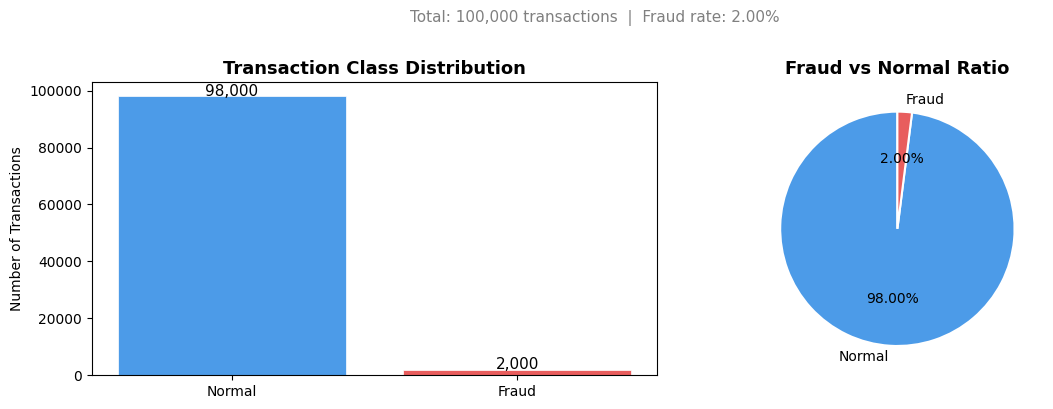

In [ ]:
# --- Class distribution ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df['is_fraud'].value_counts()

# Bar chart
bars = axes[0].bar(['Normal', 'Fraud'], counts.values,
                   color=['#4C9BE8', '#E85D5D'],
                   edgecolor='white', linewidth=0.5)

axes[0].set_title('Transaction Class Distribution', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Transactions')

for bar, count in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 200,
                 f'{count:,}', ha='center', fontsize=11)

# Pie chart
axes[1].pie(counts.values,
            labels=['Normal', 'Fraud'],
            colors=['#4C9BE8', '#E85D5D'],
            autopct='%1.2f%%',
            startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})

axes[1].set_title('Fraud vs Normal Ratio', fontsize=13, fontweight='bold')

plt.suptitle(f'Total: {len(df):,} transactions  |  Fraud rate: {counts[1]/len(df)*100:.2f}%',
             fontsize=11, color='gray', y=1.01)

plt.tight_layout()
plt.show()

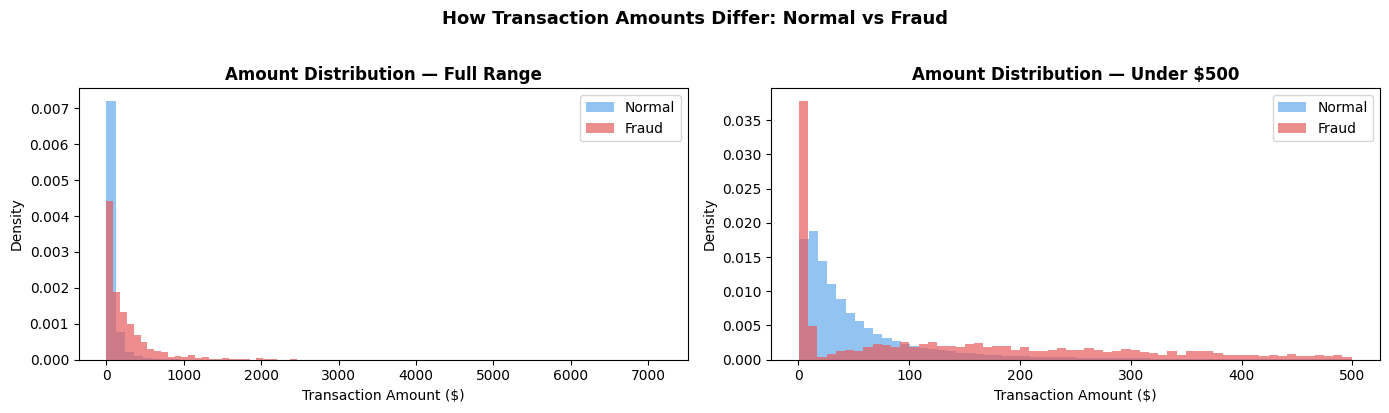

In [ ]:
# --- Transaction amount distribution ---
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Full distribution
axes[0].hist(df[df['is_fraud']==0]['amount'], bins=60,
             alpha=0.6, color='#4C9BE8', label='Normal', density=True)
axes[0].hist(df[df['is_fraud']==1]['amount'], bins=60,
             alpha=0.7, color='#E85D5D', label='Fraud', density=True)

axes[0].set_title('Amount Distribution — Full Range', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Transaction Amount ($)')
axes[0].set_ylabel('Density')
axes[0].legend()

# Zoomed in — under $500
axes[1].hist(df[(df['is_fraud']==0) & (df['amount'] < 500)]['amount'],
             bins=60, alpha=0.6, color='#4C9BE8', label='Normal', density=True)
axes[1].hist(df[(df['is_fraud']==1) & (df['amount'] < 500)]['amount'],
             bins=60, alpha=0.7, color='#E85D5D', label='Fraud', density=True)

axes[1].set_title('Amount Distribution — Under $500', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Transaction Amount ($)')
axes[1].set_ylabel('Density')
axes[1].legend()

plt.suptitle('How Transaction Amounts Differ: Normal vs Fraud',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

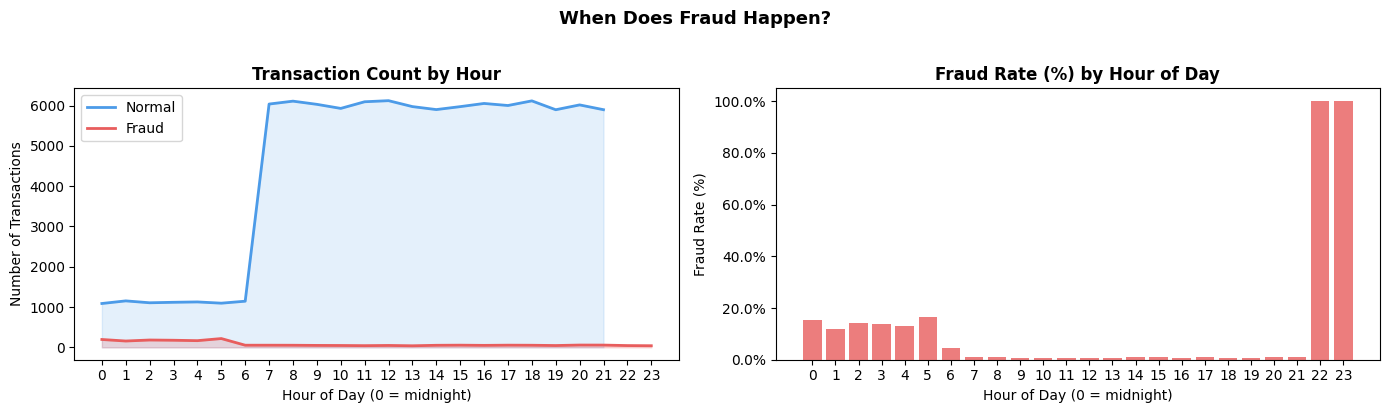

In [ ]:
# --- Fraud by hour of day ---
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Transaction count by hour
hour_fraud  = df[df['is_fraud']==1]['hour_of_day'].value_counts().sort_index()
hour_normal = df[df['is_fraud']==0]['hour_of_day'].value_counts().sort_index()

axes[0].plot(hour_normal.index, hour_normal.values,
             color='#4C9BE8', label='Normal', linewidth=2)
axes[0].fill_between(hour_normal.index, hour_normal.values,
                     alpha=0.15, color='#4C9BE8')
axes[0].plot(hour_fraud.index, hour_fraud.values,
             color='#E85D5D', label='Fraud', linewidth=2)
axes[0].fill_between(hour_fraud.index, hour_fraud.values,
                     alpha=0.2, color='#E85D5D')

axes[0].set_title('Transaction Count by Hour', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Hour of Day (0 = midnight)')
axes[0].set_ylabel('Number of Transactions')
axes[0].set_xticks(range(0, 24))
axes[0].legend()

# Fraud rate % by hour
fraud_by_hour = df.groupby('hour_of_day')['is_fraud'].mean() * 100

axes[1].bar(fraud_by_hour.index, fraud_by_hour.values,
            color='#E85D5D', alpha=0.8)
axes[1].set_title('Fraud Rate (%) by Hour of Day', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Hour of Day (0 = midnight)')
axes[1].set_ylabel('Fraud Rate (%)')
axes[1].set_xticks(range(0, 24))
axes[1].yaxis.set_major_formatter(
    plt.matplotlib.ticker.FuncFormatter(lambda x, _: f'{x:.1f}%')
)

plt.suptitle('When Does Fraud Happen?', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

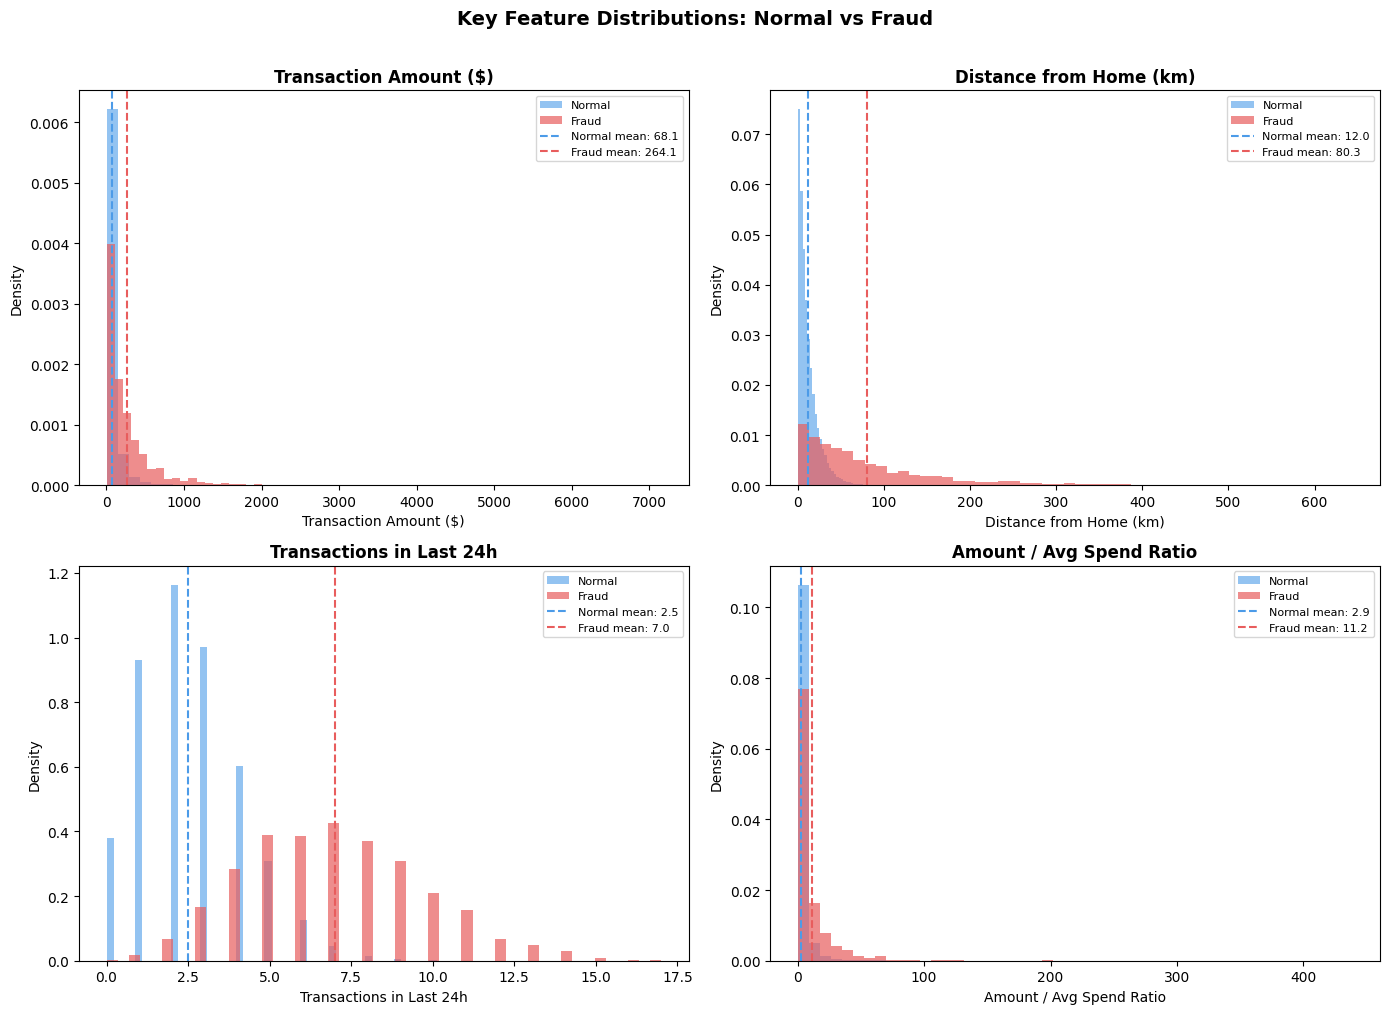

In [ ]:
# --- Key features: fraud vs normal comparison ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

features = [
    ('amount',                  'Transaction Amount ($)'),
    ('distance_from_home_km',   'Distance from Home (km)'),
    ('transactions_last_24h',   'Transactions in Last 24h'),
    ('amount_to_avg_ratio',     'Amount / Avg Spend Ratio')
]

for ax, (col, label) in zip(axes, features):
    normal_vals = df[df['is_fraud']==0][col]
    fraud_vals  = df[df['is_fraud']==1][col]

    ax.hist(normal_vals, bins=50, alpha=0.6,
            color='#4C9BE8', label='Normal', density=True)
    ax.hist(fraud_vals,  bins=50, alpha=0.7,
            color='#E85D5D', label='Fraud',  density=True)

    ax.set_title(label, fontsize=12, fontweight='bold')
    ax.set_xlabel(label)
    ax.set_ylabel('Density')
    ax.legend()

    # Add mean lines
    ax.axvline(normal_vals.mean(), color='#4C9BE8',
               linestyle='--', linewidth=1.5,
               label=f'Normal mean: {normal_vals.mean():.1f}')
    ax.axvline(fraud_vals.mean(),  color='#E85D5D',
               linestyle='--', linewidth=1.5,
               label=f'Fraud mean: {fraud_vals.mean():.1f}')
    ax.legend(fontsize=8)

plt.suptitle('Key Feature Distributions: Normal vs Fraud',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

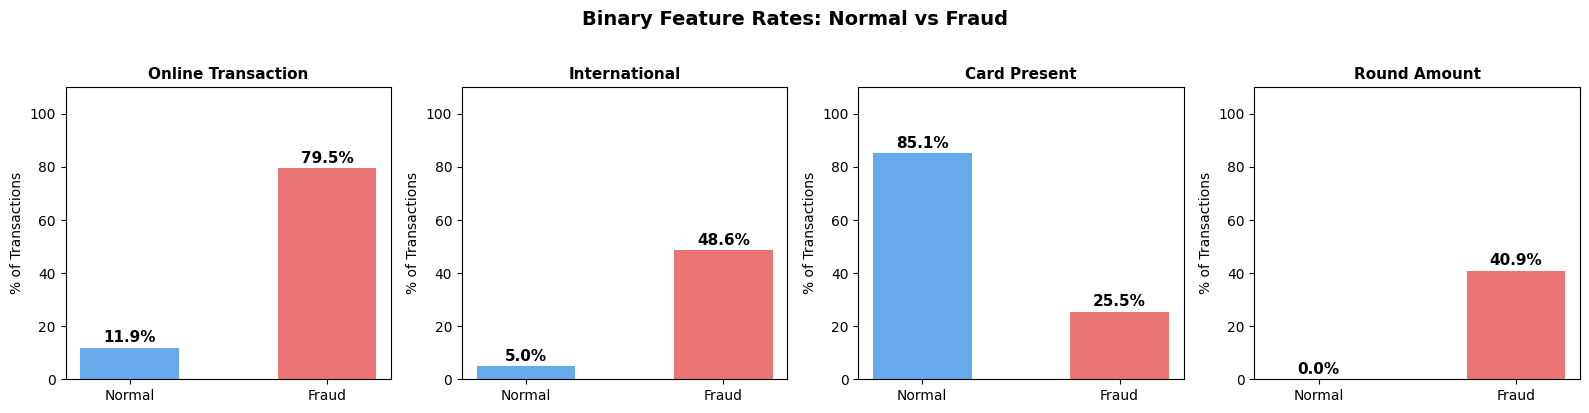

In [ ]:
# --- Binary feature comparison ---
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

binary_features = {
    'is_online':        'Online Transaction',
    'is_international': 'International',
    'card_present':     'Card Present',
    'is_round_amount':  'Round Amount'
}

for ax, (col, label) in zip(axes, binary_features.items()):
    normal_rate = df[df['is_fraud']==0][col].mean() * 100
    fraud_rate  = df[df['is_fraud']==1][col].mean() * 100

    bars = ax.bar(['Normal', 'Fraud'],
                  [normal_rate, fraud_rate],
                  color=['#4C9BE8', '#E85D5D'],
                  alpha=0.85, width=0.5)

    ax.set_title(label, fontweight='bold', fontsize=11)
    ax.set_ylabel('% of Transactions')
    ax.set_ylim(0, 110)

    for bar, val in zip(bars, [normal_rate, fraud_rate]):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 2,
                f'{val:.1f}%', ha='center',
                fontsize=11, fontweight='bold')

plt.suptitle('Binary Feature Rates: Normal vs Fraud',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

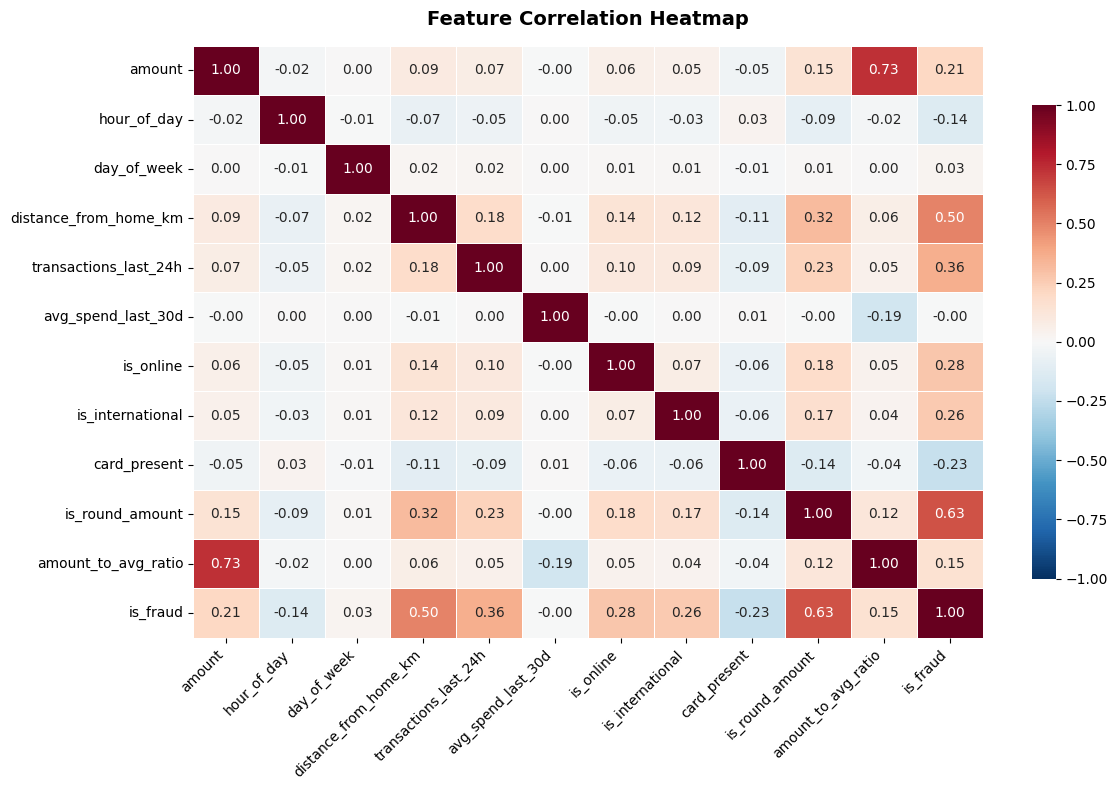

In [ ]:
# --- Correlation heatmap ---
numeric_cols = ['amount', 'hour_of_day', 'day_of_week',
                'distance_from_home_km', 'transactions_last_24h',
                'avg_spend_last_30d', 'is_online', 'is_international',
                'card_present', 'is_round_amount',
                'amount_to_avg_ratio', 'is_fraud']

plt.figure(figsize=(12, 8))

corr = df[numeric_cols].corr()

sns.heatmap(corr,
            annot=True,
            fmt='.2f',
            cmap='RdBu_r',
            center=0,
            vmin=-1, vmax=1,
            linewidths=0.5,
            cbar_kws={'shrink': 0.8})

plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

4) Preprocessing

In [26]:
# Separate features and target
X = df.drop('is_fraud', axis=1)
y = df['is_fraud']

print("Features (X) shape:", X.shape)
print("Target (y) shape:  ", y.shape)
print(f"\nNumber of features: {X.shape[1]}")
print(f"Number of transactions: {X.shape[0]:,}")
print("\nFeature columns:")
for i, col in enumerate(X.columns, 1):
    print(f"  {i:2}. {col}")

Features (X) shape: (100000, 21)
Target (y) shape:   (100000,)

Number of features: 21
Number of transactions: 100,000

Feature columns:
   1. amount
   2. hour_of_day
   3. day_of_week
   4. distance_from_home_km
   5. transactions_last_24h
   6. avg_spend_last_30d
   7. is_online
   8. is_international
   9. card_present
  10. is_round_amount
  11. amount_to_avg_ratio
  12. merchant_atm_withdrawal
  13. merchant_clothing
  14. merchant_electronics
  15. merchant_entertainment
  16. merchant_gas_station
  17. merchant_grocery
  18. merchant_online_retail
  19. merchant_pharmacy
  20. merchant_restaurant
  21. merchant_travel


In [25]:
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Training set size:', X_train.shape)
print('Testing set size: ', X_test.shape)
print(f"\nTraining transactions: {X_train.shape[0]:,} ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Testing transactions:  {X_test.shape[0]:,} ({X_test.shape[0]/len(X)*100:.0f}%)")
print(f'\nFraud cases in train: {y_train.sum()} ({y_train.mean()*100:.2f}%)')
print(f'Fraud cases in test:  {y_test.sum()} ({y_test.mean()*100:.2f}%)')

Training set size: (80000, 21)
Testing set size:  (20000, 21)

Training transactions: 80,000 (80%)
Testing transactions:  20,000 (20%)

Fraud cases in train: 1600 (2.00%)
Fraud cases in test:  400 (2.00%)


In [29]:
# Scale continuous features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Show the effect of scaling
print("BEFORE scaling — X_train stats:")
print(X_train.describe().round(2).loc[['mean', 'std', 'min', 'max'],
      ['amount', 'distance_from_home_km', 'is_online', 'transactions_last_24h']])

print("\nAFTER scaling — X_train_scaled stats:")
scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)
print(scaled_df.describe().round(2).loc[['mean', 'std', 'min', 'max'],
      ['amount', 'distance_from_home_km', 'is_online', 'transactions_last_24h']])

BEFORE scaling — X_train stats:
       amount  distance_from_home_km  is_online  transactions_last_24h
mean    72.05                  13.39       0.13                   2.59
std    131.73                  19.55       0.34                   1.73
min      0.51                   0.10       0.00                   0.00
max   3754.83                 643.80       1.00                  15.00

AFTER scaling — X_train_scaled stats:
      amount  distance_from_home_km  is_online  transactions_last_24h
mean    0.00                   0.00       0.00                  -0.00
std     1.00                   1.00       1.00                   1.00
min    -0.54                  -0.68      -0.39                  -1.49
max    27.96                  32.24       2.56                   7.16


5) Handle Class Imbalance with SMOTE

BEFORE SMOTE:
  Normal transactions: 78,400
  Fraud transactions:  1,600
  Ratio: 49:1

AFTER SMOTE:
  Normal transactions: 78,400
  Fraud transactions:  78,400
  Ratio: 1:1


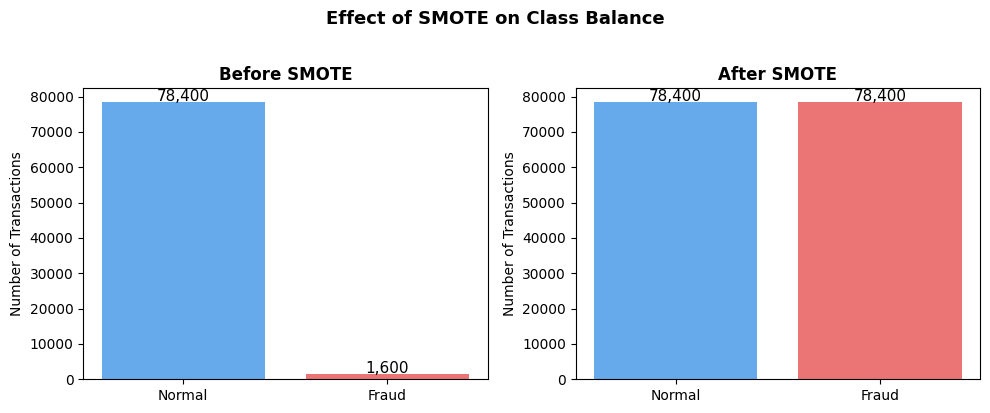

In [30]:
print("BEFORE SMOTE:")
print(f"  Normal transactions: {(y_train==0).sum():,}")
print(f"  Fraud transactions:  {(y_train==1).sum():,}")
print(f"  Ratio: {(y_train==0).sum() / (y_train==1).sum():.0f}:1")

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train_scaled, y_train)

print("\nAFTER SMOTE:")
print(f"  Normal transactions: {(y_train_sm==0).sum():,}")
print(f"  Fraud transactions:  {(y_train_sm==1).sum():,}")
print(f"  Ratio: {(y_train_sm==0).sum() / (y_train_sm==1).sum():.0f}:1")

# Visualise before and after
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, (counts, title) in zip(axes, [
    ([( y_train==0).sum(), (y_train==1).sum()],   'Before SMOTE'),
    ([(y_train_sm==0).sum(), (y_train_sm==1).sum()], 'After SMOTE')
]):
    bars = ax.bar(['Normal', 'Fraud'], counts,
                  color=['#4C9BE8', '#E85D5D'], alpha=0.85)
    ax.set_title(title, fontweight='bold', fontsize=12)
    ax.set_ylabel('Number of Transactions')
    for bar, val in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 300,
                f'{val:,}', ha='center', fontsize=11)

plt.suptitle('Effect of SMOTE on Class Balance',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

6) Train All 6 Models

In [31]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree':       DecisionTreeClassifier(max_depth=10, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'XGBoost':             XGBClassifier(n_estimators=100, random_state=42,
                                         eval_metric='logloss', verbosity=0),
    'KNN':                 KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
    'Naive Bayes':         GaussianNB()
}

results = {}

print("Training models...\n")

for name, model in models.items():
    # Train
    model.fit(X_train_sm, y_train_sm)
    
    # Predict
    y_pred  = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    
    # Evaluate
    results[name] = {
        'Accuracy':  round(accuracy_score(y_test, y_pred),  4),
        'Precision': round(precision_score(y_test, y_pred), 4),
        'Recall':    round(recall_score(y_test, y_pred),    4),
        'F1 Score':  round(f1_score(y_test, y_pred),        4),
        'ROC-AUC':   round(roc_auc_score(y_test, y_proba),  4),
        'model_obj': model,
        'y_pred':    y_pred,
        'y_proba':   y_proba
    }
    
    print(f"  {name:<22} Accuracy: {results[name]['Accuracy']:.4f}  "
          f"F1: {results[name]['F1 Score']:.4f}  "
          f"ROC-AUC: {results[name]['ROC-AUC']:.4f}")

print("\nAll models trained!")

Training models...

  Logistic Regression    Accuracy: 0.9853  F1: 0.7259  ROC-AUC: 0.9983
  Decision Tree          Accuracy: 0.9943  F1: 0.8703  ROC-AUC: 0.9739
  Random Forest          Accuracy: 0.9979  F1: 0.9484  ROC-AUC: 0.9995
  XGBoost                Accuracy: 0.9984  F1: 0.9612  ROC-AUC: 0.9995
  KNN                    Accuracy: 0.9949  F1: 0.8806  ROC-AUC: 0.9828
  Naive Bayes            Accuracy: 0.9763  F1: 0.6096  ROC-AUC: 0.9919

All models trained!


7) Model Comparision

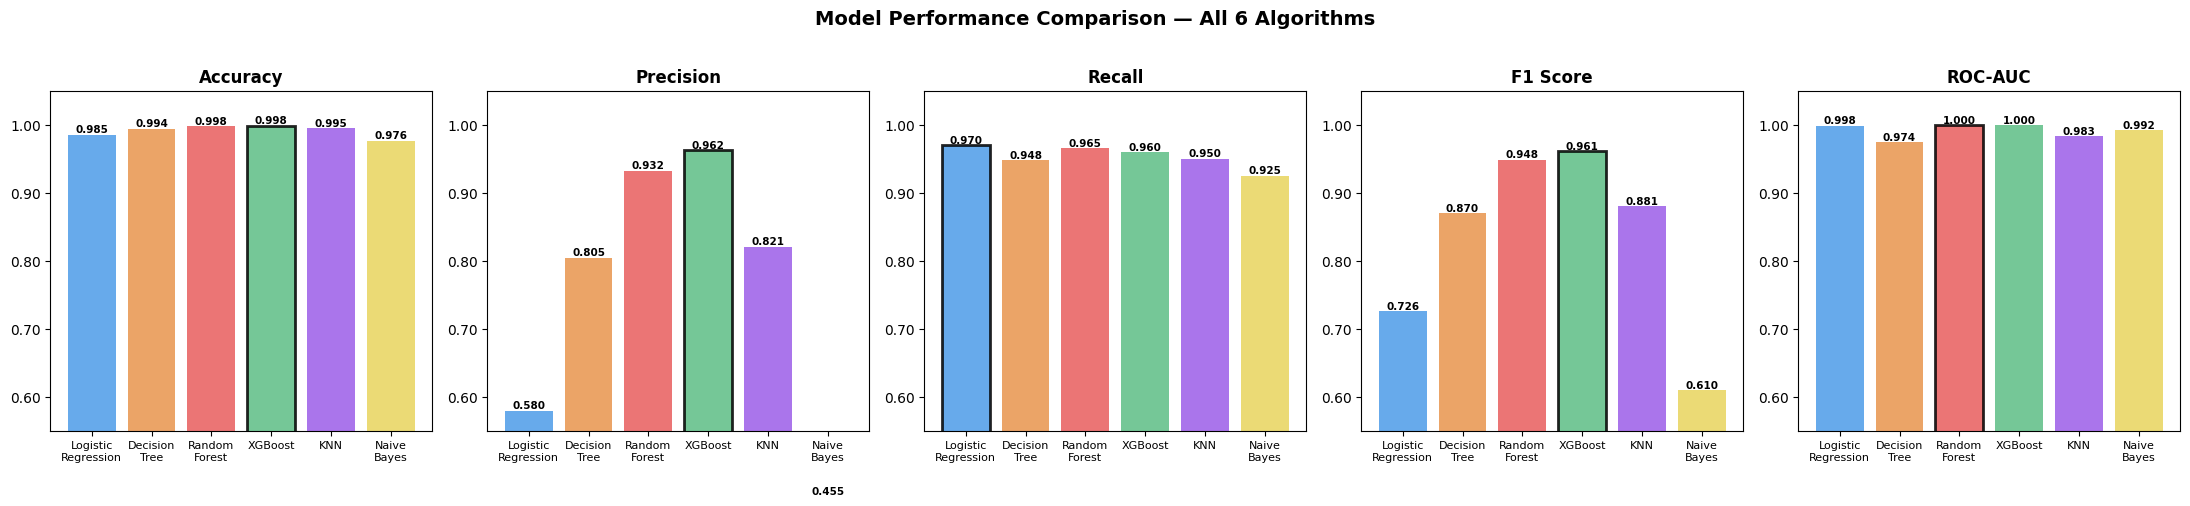

In [32]:
# Summary table
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']
model_names = list(results.keys())
colors = ['#4C9BE8', '#E8944C', '#E85D5D', '#5DBE85', '#9B5DE8', '#E8D45D']

fig, axes = plt.subplots(1, 5, figsize=(22, 5))

for ax, metric in zip(axes, metrics):
    values = [results[name][metric] for name in model_names]
    bars = ax.bar(range(len(model_names)), values,
                  color=colors, alpha=0.85)
    
    # Highlight the best bar
    best_idx = values.index(max(values))
    bars[best_idx].set_edgecolor('black')
    bars[best_idx].set_linewidth(2)
    
    ax.set_xticks(range(len(model_names)))
    ax.set_xticklabels([name.replace(' ', '\n') for name in model_names],
                       fontsize=8)
    ax.set_title(metric, fontweight='bold', fontsize=12)
    ax.set_ylim(0.55, 1.05)
    ax.yaxis.set_major_formatter(
        plt.matplotlib.ticker.FuncFormatter(lambda x, _: f'{x:.2f}')
    )
    
    # Add value labels on top of each bar
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.003,
                f'{val:.3f}', ha='center',
                fontsize=7.5, fontweight='bold')

plt.suptitle('Model Performance Comparison — All 6 Algorithms',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

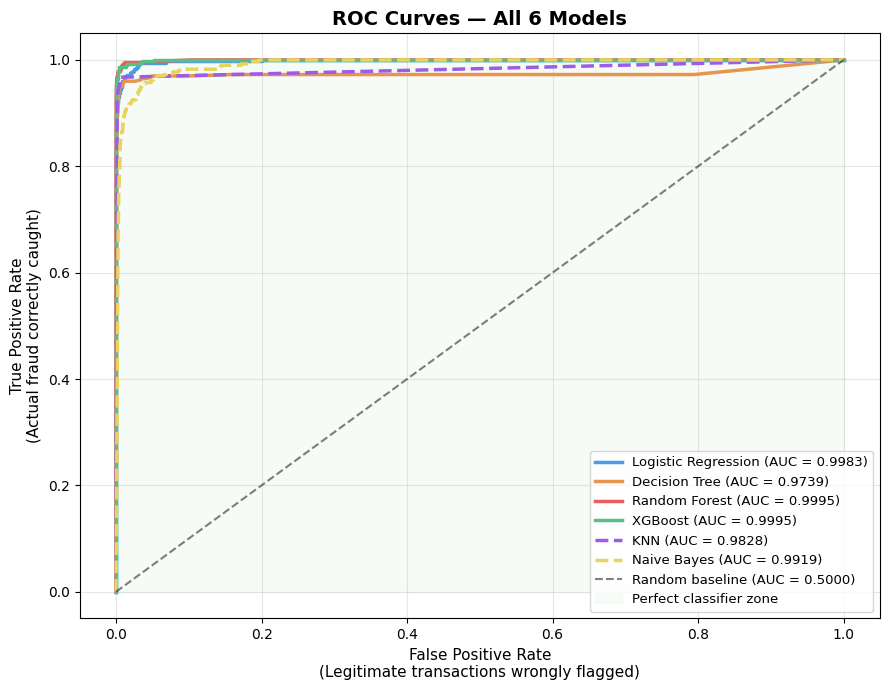

In [33]:
# --- ROC curves for all models ---
plt.figure(figsize=(9, 7))

colors = ['#4C9BE8', '#E8944C', '#E85D5D', '#5DBE85', '#9B5DE8', '#E8D45D']
line_styles = ['-', '-', '-', '-', '--', '--']

for (name, res), color, ls in zip(results.items(), colors, line_styles):
    fpr, tpr, _ = roc_curve(y_test, res['y_proba'])
    plt.plot(fpr, tpr,
             label=f"{name} (AUC = {res['ROC-AUC']:.4f})",
             color=color,
             linewidth=2.5,
             linestyle=ls)

# Random baseline
plt.plot([0, 1], [0, 1],
         'k--', linewidth=1.5,
         label='Random baseline (AUC = 0.5000)',
         alpha=0.5)

# Shade the perfect corner
plt.fill_between([0, 0, 1], [0, 1, 1],
                 alpha=0.03, color='green',
                 label='Perfect classifier zone')

plt.xlabel('False Positive Rate\n(Legitimate transactions wrongly flagged)',
           fontsize=11)
plt.ylabel('True Positive Rate\n(Actual fraud correctly caught)',
           fontsize=11)
plt.title('ROC Curves — All 6 Models', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=9.5)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

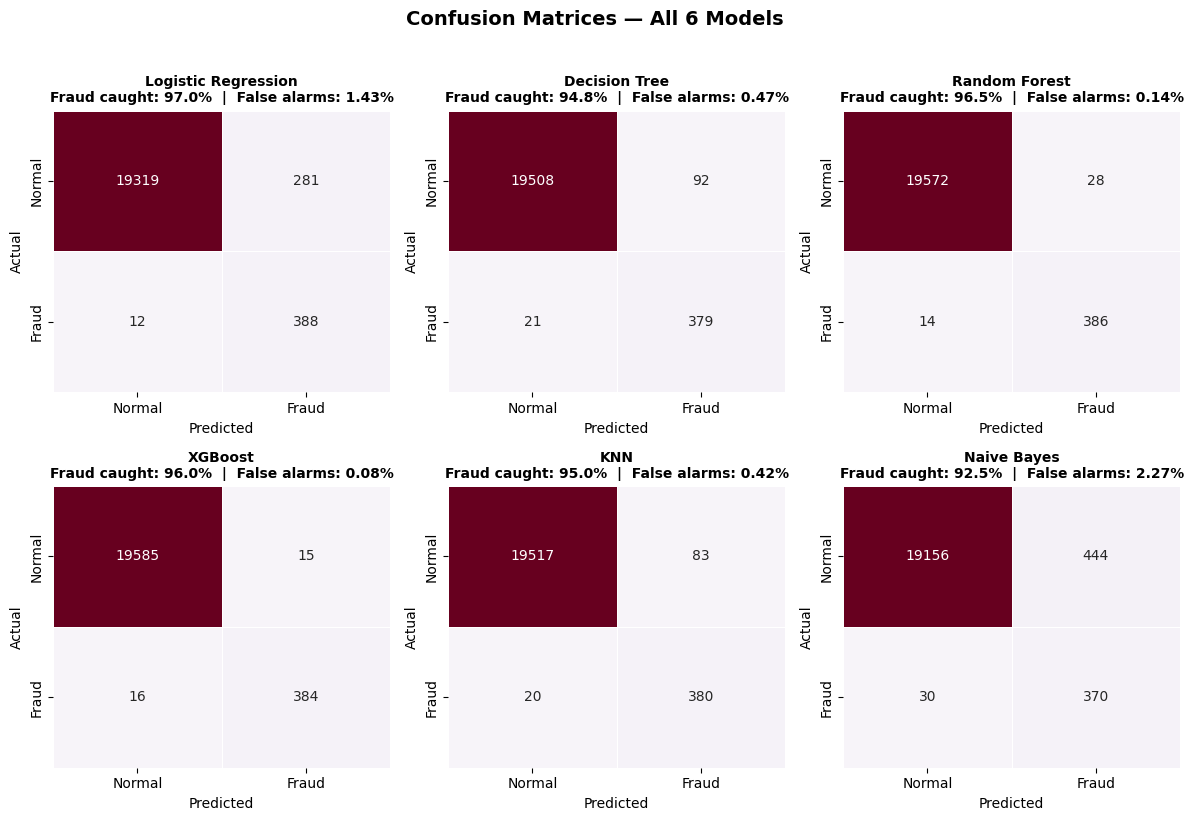

In [59]:
# --- Confusion matrices for all models ---
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()

for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    
    # Calculate rates
    tn, fp, fn, tp = cm.ravel()
    fraud_caught   = tp / (tp + fn) * 100
    false_alarms   = fp / (fp + tn) * 100
    
    sns.heatmap(cm,
                annot=True,
                fmt='d',
                cmap='PuRd',
                ax=ax,
                xticklabels=['Normal', 'Fraud'],
                yticklabels=['Normal', 'Fraud'],
                cbar=False,
                linewidths=0.5)
    
    ax.set_title(f'{name}\n'
                 f'Fraud caught: {fraud_caught:.1f}%  |  '
                 f'False alarms: {false_alarms:.2f}%',
                 fontsize=10, fontweight='bold')
    ax.set_xlabel('Predicted', fontsize=10)
    ax.set_ylabel('Actual', fontsize=10)

plt.suptitle('Confusion Matrices — All 6 Models',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [61]:
# --- Detailed classification report for best model ---
best_name  = max(results, key=lambda x: results[x]['F1 Score'])
best_model = results[best_name]['model_obj']

print(f"Best Model: {best_name}")
print(f"{'='*50}")
print(f"\nDetailed Classification Report:")
print(f"{'='*50}")
print(classification_report(y_test,
                             results[best_name]['y_pred'],
                             target_names=['Normal', 'Fraud'],
                             digits=4))

Best Model: XGBoost

Detailed Classification Report:
              precision    recall  f1-score   support

      Normal     0.9992    0.9992    0.9992     19600
       Fraud     0.9624    0.9600    0.9612       400

    accuracy                         0.9984     20000
   macro avg     0.9808    0.9796    0.9802     20000
weighted avg     0.9984    0.9984    0.9984     20000



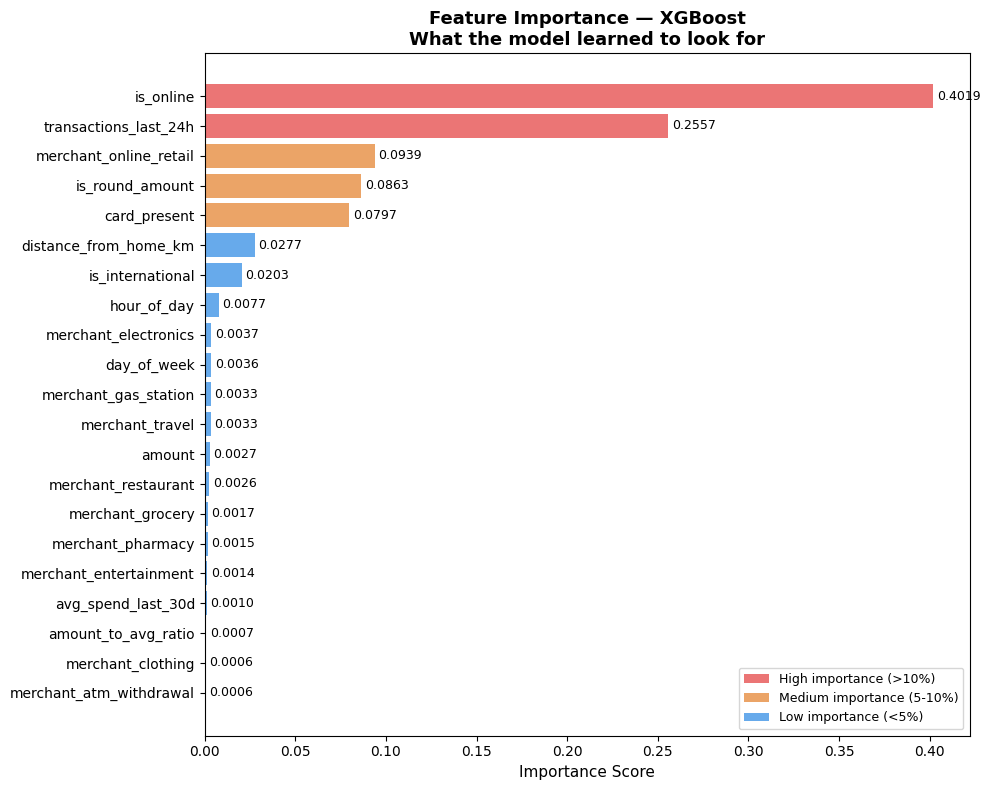

In [62]:
# --- Feature importance ---
best_name  = max(results, key=lambda x: results[x]['F1 Score'])
best_model = results[best_name]['model_obj']

# Get feature importances
importances = pd.Series(
    best_model.feature_importances_,
    index=X.columns
).sort_values(ascending=True)

# Color bars by importance level
colors = []
for val in importances.values:
    if val >= 0.10:
        colors.append('#E85D5D')
    elif val >= 0.05:
        colors.append('#E8944C')
    else:
        colors.append('#4C9BE8')

plt.figure(figsize=(10, 8))
bars = plt.barh(importances.index, importances.values,
                color=colors, alpha=0.85)

for bar, val in zip(bars, importances.values):
    plt.text(bar.get_width() + 0.002,
             bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center', fontsize=9)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#E85D5D', alpha=0.85, label='High importance (>10%)'),
    Patch(facecolor='#E8944C', alpha=0.85, label='Medium importance (5-10%)'),
    Patch(facecolor='#4C9BE8', alpha=0.85, label='Low importance (<5%)')
]
plt.legend(handles=legend_elements, loc='lower right', fontsize=9)

plt.xlabel('Importance Score', fontsize=11)
plt.title(f'Feature Importance — {best_name}\n'
          f'What the model learned to look for',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

8) Save Best Model

In [65]:
print("Saving model files...")
print("=" * 40)

metrics_list = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']

# Save everything in one file
bundle = {
    'model':            best_model,
    'scaler':           scaler,
    'model_name':       best_name,
    'feature_cols':     list(X.columns),
    'results_summary':  {
        name: {m: results[name][m] for m in metrics_list}
        for name in results
    }
}

with open('best_model.pkl', 'wb') as f:
    pickle.dump(bundle, f)

print("best_model.pkl    saved!")
print("=" * 40)
print(f"\nModel:     {best_name}")
print(f"F1 Score:  {results[best_name]['F1 Score']}")
print(f"ROC-AUC:   {results[best_name]['ROC-AUC']}")
print(f"Features:  {len(list(X.columns))} columns")

Saving model files...
best_model.pkl    saved!

Model:     XGBoost
F1 Score:  0.9612
ROC-AUC:   0.9995
Features:  21 columns


### Summary

This project built a fraud detection pipeline on **100,000 synthetic 
transactions** (2% fraud rate) comparing 6 machine learning models.

##### Key EDA Findings
- Online transactions and distance from home were the strongest fraud signals
- Fraudsters make 3x more transactions in 24h — velocity matters
- No single feature catches everything — ML is necessary

##### Model Results

| Model | Accuracy | F1 Score | ROC-AUC |
|---|---|---|---|
| **XGBoost** ✅ | 99.84% | 0.9612 | 0.9995 |
| Random Forest | 99.79% | 0.9484 | 0.9995 |
| KNN | 99.49% | 0.8806 | 0.9828 |
| Decision Tree | 99.43% | 0.8703 | 0.9739 |
| Logistic Regression | 98.53% | 0.7259 | 0.9983 |
| Naive Bayes | 97.63% | 0.6096 | 0.9919 |

#### Final Result
**XGBoost** was selected as the best model — trained on 156,800 
SMOTE-balanced samples, it achieved:
- ✅ **99.84% Accuracy**
- ✅ **0.9612 F1 Score**
- ✅ **0.9995 ROC-AUC**
- ✅ Catches **96% of all real fraud** with only **0.08% false alarms**

The model is saved and deployed via a Streamlit app where users 
can enter any transaction and receive an instant fraud verdict.